In [1]:
import pandas as pd 

df = pd.read_csv("/kaggle/input/datasets/ssssws/global-inflation-dynamics-post-covid-20202024/global_inflation_post_covid.csv")
df.head()

,country,date,inflation_rate,interest_rate,oil_price,gdp_growth,unemployment_rate,money_supply_m2,exchange_rate_usd,food_price_index,supply_chain_index
0,USA,2020-01,0.33,5.76,34.44,0.34,5.97,10558.0,69.95,94.29,3.66
1,USA,2020-02,4.12,4.33,44.75,0.02,5.80,6952.0,71.03,78.60,3.91
2,USA,2020-03,2.75,4.24,52.80,0.30,7.45,10244.0,71.00,102.91,3.70
3,USA,2020-04,4.36,4.52,39.19,2.28,5.23,9989.0,83.52,110.92,3.23
4,USA,2020-05,2.73,3.17,41.09,3.05,5.96,7982.0,70.10,86.53,3.94


In [2]:
df.isnull().sum()

country               0
date                  0
inflation_rate        0
interest_rate         0
oil_price             0
gdp_growth            0
unemployment_rate     0
money_supply_m2       0
exchange_rate_usd     0
food_price_index      0
supply_chain_index    0
dtype: int64

In [3]:
print(df.columns)

Index(['country', 'date', 'inflation_rate', 'interest_rate', 'oil_price',
       'gdp_growth', 'unemployment_rate', 'money_supply_m2',
       'exchange_rate_usd', 'food_price_index', 'supply_chain_index'],
      dtype='object')


In [4]:
df['date'] = pd.to_datetime(df['date'])
df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month

In [5]:
import numpy as np

df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)

df = df.drop(columns=['month', 'date'])

In [6]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
import matplotlib.pyplot as plt
import seaborn as sns

num = ["interest_rate", "oil_price", "gdp_growth", "unemployment_rate", "money_supply_m2", "exchange_rate_usd", "food_price_index", "supply_chain_index"]
cat = ["country"]
date = ['year', 'month_sin', 'month_cos']

<Axes: >

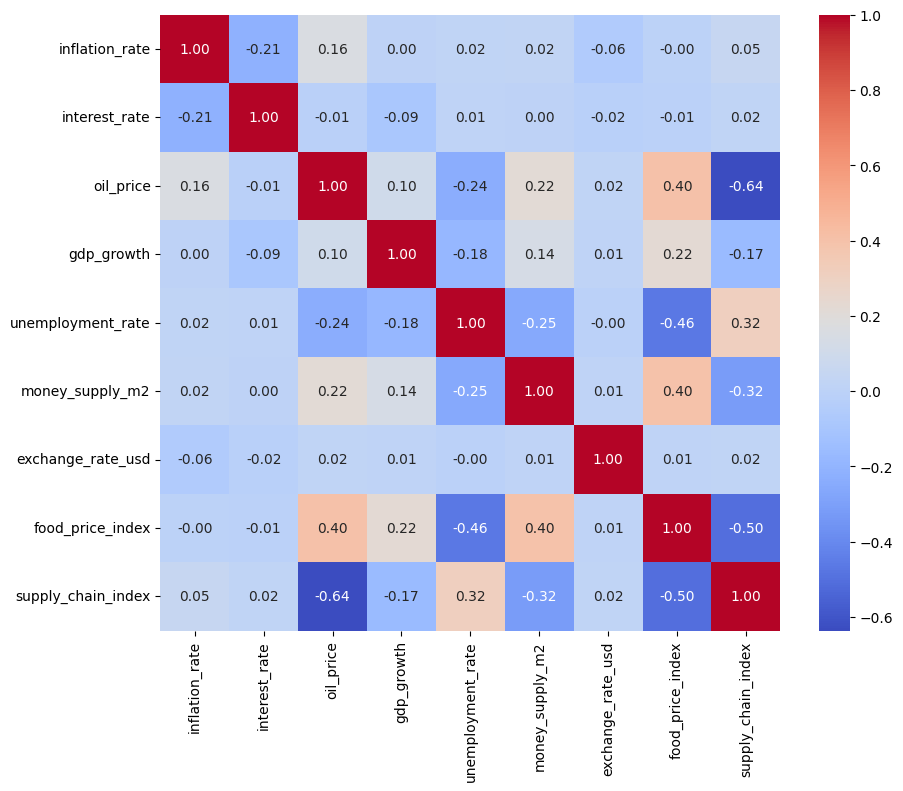

In [7]:
import seaborn as sns

numeric_cols = ['inflation_rate', 'interest_rate', 'oil_price', 'gdp_growth',
                'unemployment_rate', 'money_supply_m2', 'exchange_rate_usd',
                'food_price_index', 'supply_chain_index']

corr_matrix = df[numeric_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(
    corr_matrix,
    annot=True,         
    fmt='.2f',           
    cmap='coolwarm')

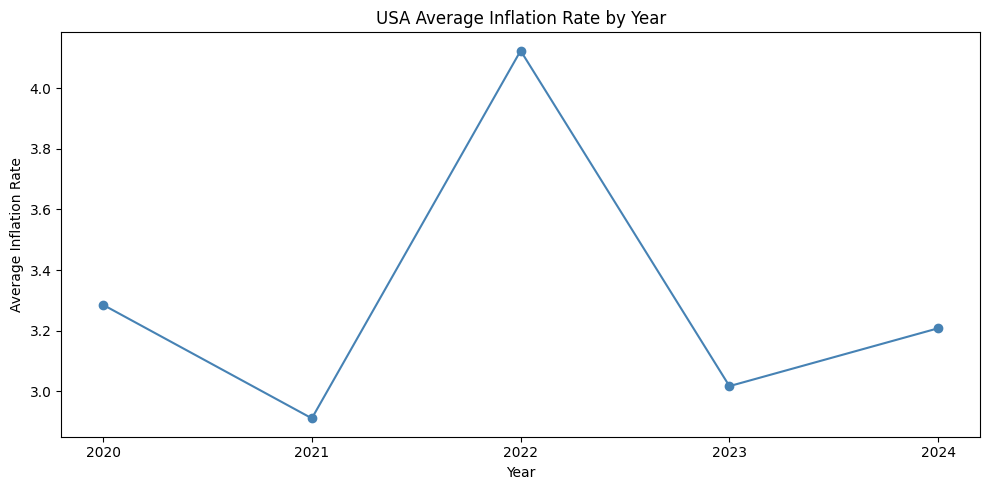

In [8]:
usa_data = df[df['country'] == 'USA'].copy()
usa_yearly = usa_data.groupby('year')['inflation_rate'].mean().reset_index()

plt.figure(figsize=(10, 5))
plt.plot(usa_yearly['year'], usa_yearly['inflation_rate'], color='steelblue', marker='o', markersize=6)

plt.title('USA Average Inflation Rate by Year')
plt.xlabel('Year')
plt.ylabel('Average Inflation Rate')
plt.xticks(usa_yearly['year'])
plt.tight_layout()
plt.show()

In [9]:
from sklearn.compose import ColumnTransformer

preprocessor_lr = ColumnTransformer(
    transformers = [
        ('cat',OneHotEncoder(),cat),
        ('num', StandardScaler(), num),
        ('date', StandardScaler(), date)
    ]
)

In [10]:
X = df.drop("inflation_rate", axis=1)
y = df["inflation_rate"]

In [11]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [12]:
pipeline = Pipeline(steps=[
    ('preprocessor_lr', preprocessor_lr),
    ('model', LinearRegression())
]
)

In [13]:
pipeline.fit(X_train, y_train)
y_pred = pipeline.predict(X_test)

In [14]:
from sklearn.metrics import r2_score
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)

print("RMSE:", rmse)
print("MAE:", mae)

r2 = r2_score(y_test, y_pred)
print("R2 score:", r2)

RMSE: 1.1104845300671953
MAE: 0.8776376530319862
R2 score: 0.41891030470365365


In [15]:
df = df.sort_values('year') 
df = df.reset_index(drop=True)

split_index = int(len(df) * 0.8)

X_train = X.iloc[:split_index]
X_test  = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test  = y.iloc[split_index:]

In [16]:
preprocessor_xg = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(), cat),
        ("num", "passthrough", num)
    ]
)

In [17]:
from sklearn.model_selection import RandomizedSearchCV
from xgboost import XGBRegressor
from scipy.stats import randint, uniform

pipeline = Pipeline([
    ('preprocessor_xg', preprocessor_xg),
    ('model', XGBRegressor(objective='reg:squarederror', random_state=42))
])

In [18]:
from sklearn.model_selection import TimeSeriesSplit

param = {
    'model__n_estimators': randint(100, 300),
    'model__max_depth': randint(3, 8),
    'model__learning_rate': uniform(0.05, 0.2)
}

tscv = TimeSeriesSplit(n_splits=5)

search = RandomizedSearchCV(
    pipeline,
    param,
    n_iter=20,
    cv=tscv,
    scoring='neg_mean_absolute_error',
    n_jobs=-1,
    random_state=42
)

search.fit(X_train, y_train)
best_model = search.best_estimator_
print(search.best_params_)

{'model__learning_rate': np.float64(0.2219880813472641), 'model__max_depth': 7, 'model__n_estimators': 172}


In [19]:
y_pred = best_model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)

print("RMSE:", rmse)
print("MAE:", mae)

r2 = r2_score(y_test, y_pred)
print("R2 score:", r2)

RMSE: 0.500998001743541
MAE: 0.40035291020576
R2 score: 0.881663549296454
